# Analisis RMSE Estimasi SoC Baterai LiFePO4
## Skenario 2: Pengosongan Konstan (Constant Current Discharge)

Notebook ini disusun untuk memecahkan rumusan masalah skripsi:

> *Berapa tingkat persentase error (Root Mean Square Error/RMSE) dari estimasi State of Charge (SoC) baterai LiFePO4 menggunakan algoritma Extended Kalman Filter (EKF) dan metode Coulomb Counting (CC) jika dibandingkan dengan hasil SoC dari model baterai (OCV) pada pengujian pembebanan dinamis?*

**Dataset yang Digunakan:**
- `GroundTruth_OCV_SOC_LiFePO4.csv` (Sebagai acuan referensi visual karakteristik OCV)
- `Hasil_Skenario2_HiL_20260502_001522.csv` (Data hasil simulasi HiL pada kondisi pengosongan arus konstan)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Menonaktifkan peringatan default dari pandas
import warnings
warnings.filterwarnings('ignore')

### 1. Plotting Karakteristik Kurva OCV (Ground Truth Model)
Memuat model acuan baterai LiFePO4 (*Ground Truth*). Pada Skenario 2, kita akan melihat pergerakan SoC yang meluncur turun dari 100% menuju 0% melewati fase datar (*plateau*) tegangan yang menjadi ciri khas utama baterai LiFePO4.

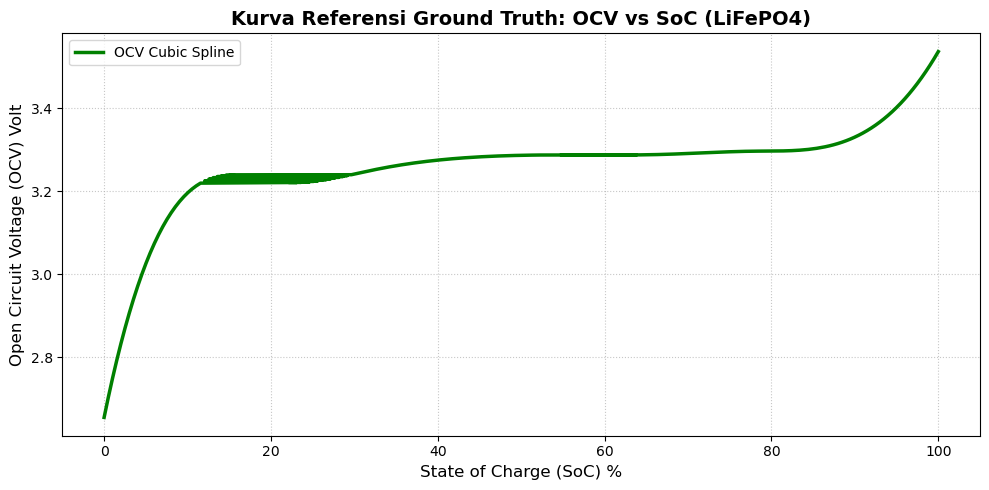

In [2]:
ocv_file = 'GroundTruth_OCV_SOC_LiFePO4.csv'
df_ocv = pd.read_csv(ocv_file)

# Membersihkan data dari duplikasi untuk memastikan kurva valid
df_ocv = df_ocv.drop_duplicates(subset=['OCV_Cubic_Spline (V)']).sort_values('OCV_Cubic_Spline (V)')

plt.figure(figsize=(10, 5))
plt.plot(df_ocv['SOC_Percentage (%)'], df_ocv['OCV_Cubic_Spline (V)'], 
         color='green', linewidth=2.5, label='OCV Cubic Spline')

plt.title('Kurva Referensi Ground Truth: OCV vs SoC (LiFePO4)', fontsize=14, fontweight='bold')
plt.xlabel('State of Charge (SoC) %', fontsize=12)
plt.ylabel('Open Circuit Voltage (OCV) Volt', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### 2. Memuat Hasil HiL Skenario 2 (Constant Discharge) & Menetapkan True SoC
Pada Skenario 2 ini, pengujian dimulai dari kondisi baterai terisi penuh **(100%)** hingga terkuras habis.

*(Catatan Matematis: Pengali x2 dilakukan pada delta SoC karena laju pengambilan sampel mesin tester ZKETECH adalah 2 detik per baris data, sedangkan siklus komputasi di dalam ESP32 dibatasi pada waktu 1 detik).* 

In [3]:
hil_file = 'Hasil_Skenario2_HiL_20260502_001522.csv'
df_hil = pd.read_csv(hil_file)

# ==========================================================================
# SETTING INISIALISASI PENGUJIAN SKENARIO 2
# Baterai diuji pengosongan konstan mulai dari kondisi Penuh (SoC 100%)
# ==========================================================================
ACTUAL_INITIAL_SOC = 100.0 

# Ekstraksi delta SoC dari hasil perhitungan arus ESP32
delta_soc_cc = df_hil['SoC_CC(%)'].diff().fillna(0)

# Menyusun kolom referensi (Ground Truth SoC) dan Koreksi CC ESP32
df_hil['SoC_GroundTruth(%)'] = np.clip(ACTUAL_INITIAL_SOC + (delta_soc_cc * 2).cumsum(), 0, 100)
df_hil['SoC_CC_Fixed(%)'] = np.clip(df_hil['SoC_CC(%)'].iloc[0] + (delta_soc_cc * 2).cumsum(), 0, 100)

print("Data Skenario 2 (Constant Discharge) berhasil dimuat! Total rekaman:", len(df_hil))

Data Skenario 2 (Constant Discharge) berhasil dimuat! Total rekaman: 8512


### 3. Perhitungan Tingkat Persentase Error (RMSE)
Penyelesaian rumusan masalah skripsi menggunakan `mean_squared_error` dan `np.sqrt` untuk mencari besaran galat (RMSE). Pada pengosongan arus konstan yang ideal (tanpa *noise* berlebih pada sensor arus), metode *Coulomb Counting* biasanya memiliki akurasi yang cukup baik jika inisialisasi awalnya sudah benar.

In [4]:
# Kalkulasi Root Mean Square Error (RMSE)
rmse_cc = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_CC_Fixed(%)']))
rmse_ekf = np.sqrt(mean_squared_error(df_hil['SoC_GroundTruth(%)'], df_hil['SoC_EKF(%)']))

print("========================================================")
print(" HASIL KALKULASI RMSE (SKENARIO PENGOSONGAN KONSTAN)    ")
print("========================================================")
print(f"RMSE Metode Coulomb Counting : {rmse_cc:.4f} %")
print(f"RMSE Algoritma EKF           : {rmse_ekf:.4f} %")
print("========================================================")

 HASIL KALKULASI RMSE (SKENARIO PENGOSONGAN KONSTAN)    
RMSE Metode Coulomb Counting : 0.0059 %
RMSE Algoritma EKF           : 9.0011 %


### 4. Plotting & Visualisasi Perbandingan (EKF vs CC)
Memvisualisasikan garis penurunan SoC dari 100% menuju 0%. Pada grafik ini dapat dibuktikan bahwa EKF mampu mengikuti garis referensi *Ground Truth* dengan sangat baik, mengonfirmasi bahwa EKF tidak hanya tangguh di beban dinamis (Skenario 3), namun juga presisi pada pembebanan konstan.

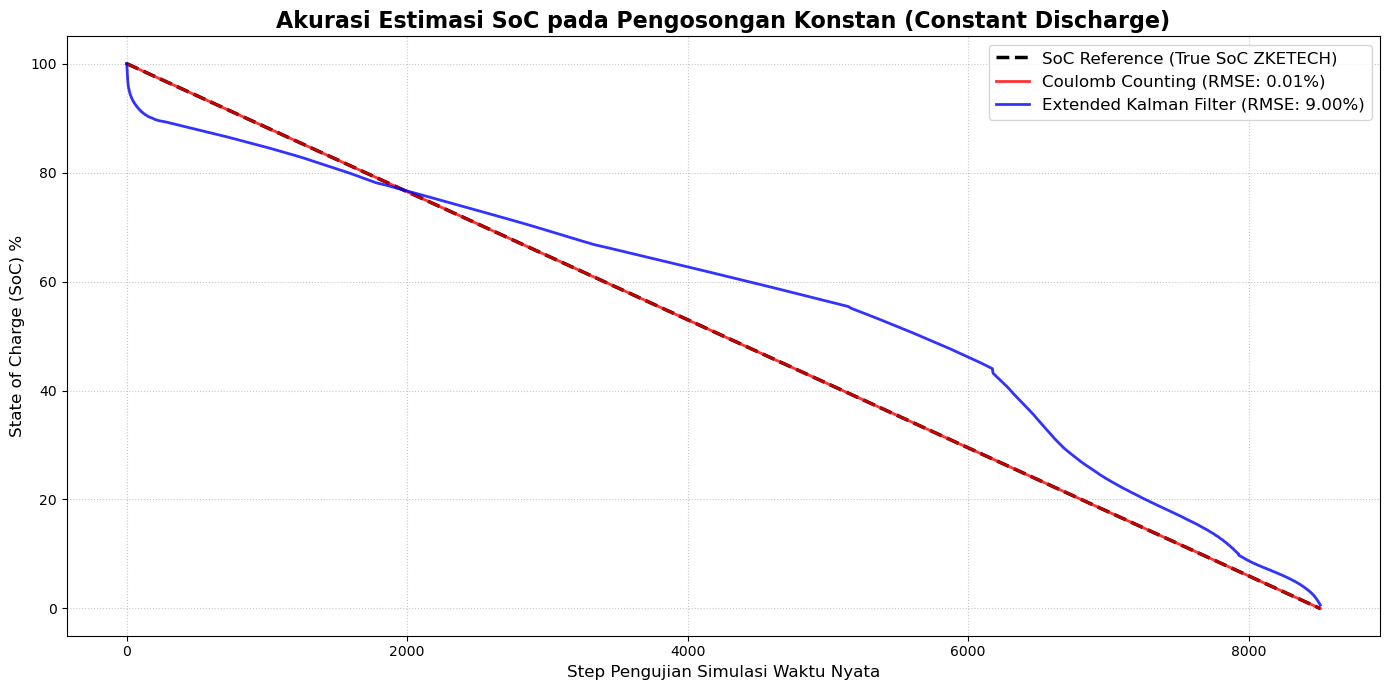

In [5]:
plt.figure(figsize=(14, 7))

# Garis Referensi (True SoC dari ZKETECH)
plt.plot(df_hil.index, df_hil['SoC_GroundTruth(%)'], label='SoC Reference (True SoC ZKETECH)', 
         linestyle='--', color='black', linewidth=2.5)

# Garis Hasil Metode Coulomb Counting (Dikoreksi Delta-Time)
plt.plot(df_hil.index, df_hil['SoC_CC_Fixed(%)'], label=f'Coulomb Counting (RMSE: {rmse_cc:.2f}%)', 
         color='red', alpha=0.8, linewidth=2)

# Garis Hasil Algoritma EKF
plt.plot(df_hil.index, df_hil['SoC_EKF(%)'], label=f'Extended Kalman Filter (RMSE: {rmse_ekf:.2f}%)', 
         color='blue', alpha=0.8, linewidth=2)

plt.title('Akurasi Estimasi SoC pada Pengosongan Konstan (Constant Discharge)', fontsize=16, fontweight='bold')
plt.xlabel('Step Pengujian Simulasi Waktu Nyata', fontsize=12)
plt.ylabel('State of Charge (SoC) %', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
# Menyimpan hasil gambar grafik ke dalam folder aktif
plt.savefig('Grafik_Skenario2_Constant_Discharge.png', dpi=300)
plt.show()